In [1]:
import pandas as pd

In [3]:
pesticides = pd.read_csv("../Prediction/pesticides.csv")
pesticides.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [4]:
print("format:" , pesticides.shape)
print("-----------------------------")
print("Doublon:" , pesticides.duplicated().sum())
print("-----------------------------")
print("Valeur manquantes:" , pesticides.isnull())
print("-----------------------------")
print("Total valeur manquantes:" , pesticides.isnull().sum().sum())


format: (4349, 7)
-----------------------------
Doublon: 0
-----------------------------
Valeur manquantes:       Domain   Area  Element   Item   Year   Unit  Value
0      False  False    False  False  False  False  False
1      False  False    False  False  False  False  False
2      False  False    False  False  False  False  False
3      False  False    False  False  False  False  False
4      False  False    False  False  False  False  False
...      ...    ...      ...    ...    ...    ...    ...
4344   False  False    False  False  False  False  False
4345   False  False    False  False  False  False  False
4346   False  False    False  False  False  False  False
4347   False  False    False  False  False  False  False
4348   False  False    False  False  False  False  False

[4349 rows x 7 columns]
-----------------------------
Total valeur manquantes: 0


In [5]:
pesticides["Item"].value_counts()

Item
Pesticides (total)    4349
Name: count, dtype: int64

In [6]:
pesticides["Area"].value_counts()

Area
Albania                27
Algeria                27
Angola                 27
Antigua and Barbuda    27
Argentina              27
                       ..
Montenegro             11
Belgium-Luxembourg     10
Sudan                   5
USSR                    2
Yugoslav SFR            2
Name: count, Length: 168, dtype: int64

In [7]:
pesticides["Element"].value_counts()

Element
Use    4349
Name: count, dtype: int64

<Axes: >

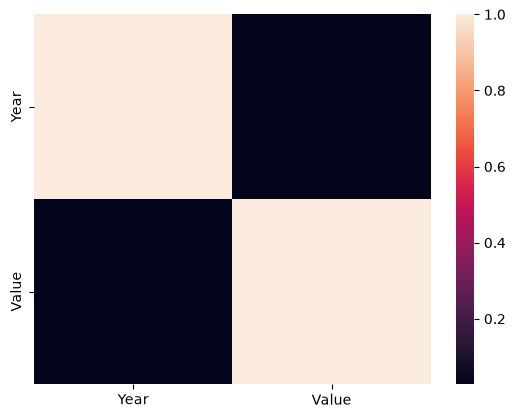

In [8]:
# Prenons en compte les corrélations
correlation = pesticides.select_dtypes(include=["int64","float64"])
correlation = correlation.corr()
import seaborn as sns
sns.heatmap(correlation)

* Conclusion

In [9]:
rainfall = pd.read_csv("../Prediction/rainfall.csv")
rainfall.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [10]:
print("format:" , rainfall.shape)
print("-----------------------------")
print("Doublon:" , rainfall.duplicated().sum())
print("-----------------------------")
print("Valeur manquantes:" , rainfall.isnull())
print("-----------------------------")
print("Total valeur manquantes:" , rainfall.isnull().sum().sum())


format: (6727, 3)
-----------------------------
Doublon: 0
-----------------------------
Valeur manquantes:        Area   Year  average_rain_fall_mm_per_year
0     False  False                          False
1     False  False                          False
2     False  False                          False
3     False  False                          False
4     False  False                          False
...     ...    ...                            ...
6722  False  False                          False
6723  False  False                          False
6724  False  False                          False
6725  False  False                          False
6726  False  False                          False

[6727 rows x 3 columns]
-----------------------------
Total valeur manquantes: 774


In [11]:
rainfall.columns

Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [12]:
rainfall[' Area'].value_counts()
rainfall[' Area'].isnull().sum().sum()

np.int64(0)

In [13]:
rainfall['Year'].value_counts()
rainfall['Year'].isnull().sum().sum()

np.int64(0)

In [14]:
rainfall['average_rain_fall_mm_per_year'].value_counts()
rainfall['average_rain_fall_mm_per_year'].isnull().sum().sum()

np.int64(774)

In [15]:
rainfall['average_rain_fall_mm_per_year'].unique()

array(['327', '1485', '89', nan, '1010', '1030', '591', '562', '534',
       '1110', '447', '..', '1292', '83', '2666', '1422', '618', '847',
       '1705', '1039', '2200', '1146', '1028', '416', '1761', '2722',
       '608', '748', '1274', '228', '1904', '1604', '537', '1342', '322',
       '1522', '645', '3240', '900', '1543', '1646', '2926', '1348',
       '1113', '1335', '498', '677', '703', '220', '2083', '1410', '2274',
       '51', '1784', '2156', '383', '626', '788', '848', '2592', '536',
       '867', '1831', '836', '1026', '700', '1187', '652', '2350', '1996',
       '1651', '1577', '2387', '1440', '1976', '589', '1940', '1083',
       '2702', '216', '1118', '435', '832', '2051', '1668', '111', '250',
       '630', '1054', '121', '533', '1834', '641', '661', '2391', '56',
       '656', '934', '619', '1513', '1181', '2875', '1972', '282', '560',
       '92', '2041', '758', '450', '241', '346', '1032', '2091', '285',
       '1500', '778', '1732', '2280', '151', '1150', '1414', 

* Nous constatons que notre dernière colonne au lieu être int c'est une colonne object 

In [16]:
rainfall['average_rain_fall_mm_per_year'] = pd.to_numeric(
    rainfall['average_rain_fall_mm_per_year'],
    errors='coerce'
)

In [17]:
# description
rainfall['average_rain_fall_mm_per_year'].describe()

count    5947.000000
mean     1124.743232
std       786.257365
min        51.000000
25%       534.000000
50%      1010.000000
75%      1651.000000
max      3240.000000
Name: average_rain_fall_mm_per_year, dtype: float64

In [18]:
# Donc c'est notre notre dernière colonne qui contient ces valeurs manquantes
len(rainfall['average_rain_fall_mm_per_year'])

6727

* Pourcentage de valeurs manquantes par colonnes

In [19]:
missing_percent = rainfall.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

average_rain_fall_mm_per_year    11.595065
 Area                             0.000000
Year                              0.000000
dtype: float64


* Comme c'est la seule colonne qui contient des valeurs manquantes donc ça devient facile nous allons emputer par la mediane au lieu de perdre 11.5 % de nos données

In [20]:
rainfall['average_rain_fall_mm_per_year'] = (
    rainfall['average_rain_fall_mm_per_year']
    .fillna(
        rainfall['average_rain_fall_mm_per_year'].median()
    )
)

In [21]:
rainfall['average_rain_fall_mm_per_year'].isnull().sum()

np.int64(0)

* Conclusion
    * Donc on peut retenir que dans ce jeu de données nous avons les informations nécessaires sur le climat pluviométrique . A présent ce jeu donnée sera fusionné avec les autres pour avoir un dataset enrichi contenant les informations nécéssaires dans la phase de modélisation  

In [22]:
temp = pd.read_csv("../Prediction/temp.csv")
temp.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [23]:
temp['country'].value_counts()

country
United States       11973
China                6172
India                4756
Russia               2257
Brazil               1997
                    ...  
Mozambique            157
Lesotho               157
Eritrea               150
Peru                  133
Papua New Guinea      132
Name: count, Length: 137, dtype: int64

In [24]:
# Pourcentage de valeurs manquantes par colonnes
missing_percent = temp.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

avg_temp    3.571679
year        0.000000
country     0.000000
dtype: float64


In [25]:
temp['avg_temp']

0        25.58
1        25.52
2        25.67
3          NaN
4          NaN
         ...  
71306    21.76
71307    20.90
71308    21.55
71309    21.52
71310    22.19
Name: avg_temp, Length: 71311, dtype: float64

* La colonne contenant des nan est la avg_temp donc à présent nous pouvons supprimer ces lignes mais nous allons envisager l'imputation par la median

In [26]:
temp['avg_temp'] = (
    temp['avg_temp']
    .fillna(
        temp['avg_temp'].median()
    )
)

* Conclusion
    * Dans ce jeu de donnée nous avons les informations sur la température en fonction du pays et de l'année 

In [27]:
yield_df = pd.read_csv("../Prediction/yield_df.csv")
yield_df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [28]:
print("format:" , yield_df.shape)
print("-----------------------------")
print("Doublon:" , yield_df.duplicated().sum())
print("-----------------------------")
print("Valeur manquantes:" , yield_df.isnull())
print("-----------------------------")
print("Total valeur manquantes:" , yield_df.isnull().sum().sum())


format: (28242, 8)
-----------------------------
Doublon: 0
-----------------------------
Valeur manquantes:        Unnamed: 0   Area   Item   Year  hg/ha_yield  \
0           False  False  False  False        False   
1           False  False  False  False        False   
2           False  False  False  False        False   
3           False  False  False  False        False   
4           False  False  False  False        False   
...           ...    ...    ...    ...          ...   
28237       False  False  False  False        False   
28238       False  False  False  False        False   
28239       False  False  False  False        False   
28240       False  False  False  False        False   
28241       False  False  False  False        False   

       average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                              False              False     False  
1                              False              False     False  
2                         

In [29]:
# Pourcentage de valeurs manquantes par colonnes
missing_percent = yield_df.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

Unnamed: 0                       0.0
Area                             0.0
Item                             0.0
Year                             0.0
hg/ha_yield                      0.0
average_rain_fall_mm_per_year    0.0
pesticides_tonnes                0.0
avg_temp                         0.0
dtype: float64


* Nous constatons que ce jeu de donnée contient les données essentielles d'une prédiction donc nous allons le garder pour une comparaison avec nos jointures ultérieures

In [30]:
yielde = pd.read_csv("../Prediction/yield.csv")
yielde.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [31]:
# Pourcentage de valeurs manquantes par colonnes
missing_percent = yielde.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

Domain Code     0.0
Domain          0.0
Area Code       0.0
Area            0.0
Element Code    0.0
Element         0.0
Item Code       0.0
Item            0.0
Year Code       0.0
Year            0.0
Unit            0.0
Value           0.0
dtype: float64


In [32]:
print("format:" , yielde.shape)
print("-----------------------------")
print("Doublon:" , yielde.duplicated().sum())
print("-----------------------------")
print("Valeur manquantes:" , yielde.isnull())
print("-----------------------------")
print("Total valeur manquantes:" , yielde.isnull().sum().sum())


format: (56717, 12)
-----------------------------
Doublon: 0
-----------------------------
Valeur manquantes:        Domain Code  Domain  Area Code   Area  Element Code  Element  \
0            False   False      False  False         False    False   
1            False   False      False  False         False    False   
2            False   False      False  False         False    False   
3            False   False      False  False         False    False   
4            False   False      False  False         False    False   
...            ...     ...        ...    ...           ...      ...   
56712        False   False      False  False         False    False   
56713        False   False      False  False         False    False   
56714        False   False      False  False         False    False   
56715        False   False      False  False         False    False   
56716        False   False      False  False         False    False   

       Item Code   Item  Year Code   

In [33]:
pesticides.columns

Index(['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')

In [34]:
rainfall.columns

Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [35]:
pesticides['Area'].nunique()

168

In [36]:
pesticides['Year'].nunique()

27

In [37]:
rainfall.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327.0
1,Afghanistan,1986,327.0
2,Afghanistan,1987,327.0
3,Afghanistan,1989,327.0
4,Afghanistan,1990,327.0


In [38]:
rainfall[' Area']

0       Afghanistan
1       Afghanistan
2       Afghanistan
3       Afghanistan
4       Afghanistan
           ...     
6722       Zimbabwe
6723       Zimbabwe
6724       Zimbabwe
6725       Zimbabwe
6726       Zimbabwe
Name:  Area, Length: 6727, dtype: object

In [39]:
rainfall['Year'].nunique()

31

In [40]:
rainfall[' Area'].nunique()

217

In [41]:
temp.columns

Index(['year', 'country', 'avg_temp'], dtype='object')

In [42]:
# Effectuons un replace sur nos jeux de données pour une uniformité
rainfall.columns


Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [43]:
rainfall.columns = rainfall.columns.str.strip()

In [44]:
rainfall['Area']

0       Afghanistan
1       Afghanistan
2       Afghanistan
3       Afghanistan
4       Afghanistan
           ...     
6722       Zimbabwe
6723       Zimbabwe
6724       Zimbabwe
6725       Zimbabwe
6726       Zimbabwe
Name: Area, Length: 6727, dtype: object

In [45]:
pesticides.columns

Index(['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')

In [46]:
pesticides.columns = pesticides.columns.str.lower()
rainfall.columns = rainfall.columns.str.lower()

In [47]:
rainfall.columns

Index(['area', 'year', 'average_rain_fall_mm_per_year'], dtype='object')

In [48]:
pesticides.columns

Index(['domain', 'area', 'element', 'item', 'year', 'unit', 'value'], dtype='object')

In [49]:
temp.columns

Index(['year', 'country', 'avg_temp'], dtype='object')

In [50]:
yielde.columns

Index(['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element',
       'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value'],
      dtype='object')

In [51]:
yielde.columns = yielde.columns.str.lower()

In [52]:
yielde.columns

Index(['domain code', 'domain', 'area code', 'area', 'element code', 'element',
       'item code', 'item', 'year code', 'year', 'unit', 'value'],
      dtype='object')

In [53]:
yield_df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [54]:
print(pesticides.columns)
print(rainfall.columns)
print(temp.columns)
print(yielde.columns)

Index(['domain', 'area', 'element', 'item', 'year', 'unit', 'value'], dtype='object')
Index(['area', 'year', 'average_rain_fall_mm_per_year'], dtype='object')
Index(['year', 'country', 'avg_temp'], dtype='object')
Index(['domain code', 'domain', 'area code', 'area', 'element code', 'element',
       'item code', 'item', 'year code', 'year', 'unit', 'value'],
      dtype='object')


* Cherchons la colonne clé pour la jointure

In [55]:
common = set(rainfall['area'].unique()) & set(pesticides['area'].unique())
only_rain = set(rainfall['area'].unique()) - set(pesticides['area'].unique())
only_pest = set(pesticides['area'].unique()) - set(rainfall['area'].unique())

print(f"Pays communs: {len(common)}")
print(f"Seulement dans rain: {only_rain}")
print(f"Seulement dans pest: {only_pest}")

Pays communs: 138
Seulement dans rain: {'Kosovo', 'Dominica', 'Eswatini', 'Sint Maarten (Dutch part)', 'Uzbekistan', 'Micronesia', 'Grenada', 'Guam', 'Czech Republic', 'United States', 'Congo, Rep.', 'Mongolia', 'Gabon', 'Djibouti', 'South Sudan', 'Macao SAR, China', 'Equatorial Guinea', 'China', 'Georgia', 'Afghanistan', 'Isle of Man', 'Congo, Dem. Rep.', 'Virgin Islands (U.S.)', 'Hong Kong SAR, China', 'St. Vincent and the Grenadines', 'Kyrgyz Republic', 'Moldova', 'Cuba', 'Curacao', 'Nigeria', 'Lao PDR', 'Tanzania', 'Cayman Islands', 'Venezuela, RB', 'Faroe Islands', 'Greenland', 'Philippines', 'West Bank and Gaza', 'Vietnam', 'Nauru', 'South Korea ', 'Tuvalu', 'Iran', 'St. Kitts and Nevis', 'Sierra Leone', 'Kiribati', 'North Korea', 'Macedonia', 'Cambodia', 'Aruba', 'Palau', 'Puerto Rico', "Cote d'Ivoire", 'Solomon Islands', 'Northern Mariana Islands', 'Bosnia and Herzegovina', 'United Arab Emirates', 'Somalia', 'St. Lucia', 'Gibraltar', 'Slovak Republic', 'Russia', 'Marshall Islan

In [56]:
yield_df.columns = yield_df.columns.str.lower()

In [57]:
temp

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,16.14
4,1853,Côte D'Ivoire,16.14
...,...,...,...
71306,2009,Mexico,21.76
71307,2010,Mexico,20.90
71308,2011,Mexico,21.55
71309,2012,Mexico,21.52


In [58]:
print(temp.shape)
print(rainfall.shape)
print(pesticides.shape)
print(yielde.shape)
print(yield_df.shape)

(71311, 3)
(6727, 3)
(4349, 7)
(56717, 12)
(28242, 8)


In [59]:
# Nous constatons que notre jeu de donnée temp contient une colonne country que nous allons rénommer pour avoir area
temp.rename(
    columns={
        "country": "area"
    },
    inplace=True
)

In [60]:
yield_df

,unnamed: 0,area,item,year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.00,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.00,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.00,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.00,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.00,16.37
...,...,...,...,...,...,...,...,...
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76


In [61]:
yielde

,domain code,domain,area code,area,element code,element,item code,item,year code,year,unit,value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400
...,...,...,...,...,...,...,...,...,...,...,...,...
56712,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420
56713,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2013,2013,hg/ha,22888
56714,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2014,2014,hg/ha,21357
56715,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2015,2015,hg/ha,19826


* A présent place à la fusion des jeux de données 

In [62]:
# Fusion de rainfall et temp
df = rainfall.merge(
    temp,
    on=['area',"year"],
    how="inner"
)
print(df.shape)

(8802, 4)


In [63]:
df

,area,year,average_rain_fall_mm_per_year,avg_temp
0,Afghanistan,1985,327.0,15.52
1,Afghanistan,1986,327.0,14.71
2,Afghanistan,1987,327.0,15.46
3,Afghanistan,1989,327.0,14.46
4,Afghanistan,1990,327.0,15.45
...,...,...,...,...
8797,Zimbabwe,2009,657.0,20.52
8798,Zimbabwe,2010,657.0,21.17
8799,Zimbabwe,2011,657.0,20.78
8800,Zimbabwe,2012,657.0,20.52


In [64]:
# A présent récupérons pesticides avec le df
df = df.merge(
    pesticides,
    on=['area','year'],
    how="inner"
)
print(df.shape)

(4437, 9)


In [65]:
df

,area,year,average_rain_fall_mm_per_year,avg_temp,domain,element,item,unit,value
0,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00
1,Albania,1991,1485.0,15.36,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00
2,Albania,1992,1485.0,16.06,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00
3,Albania,1993,1485.0,16.05,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00
4,Albania,1994,1485.0,16.96,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,201.00
...,...,...,...,...,...,...,...,...,...
4432,Zimbabwe,2009,657.0,20.52,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,3269.99
4433,Zimbabwe,2010,657.0,21.17,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,3305.17
4434,Zimbabwe,2011,657.0,20.78,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,3340.35
4435,Zimbabwe,2012,657.0,20.52,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,3375.53


In [66]:
# A présent yielde avec df
df = df.merge(
    yielde,
    on=['area','year'],
    how="inner"
)
print(df.shape)

(28248, 19)


In [67]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(28248, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28248 entries, 0 to 28247
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   area                           28248 non-null  object 
 1   year                           28248 non-null  int64  
 2   average_rain_fall_mm_per_year  28248 non-null  float64
 3   avg_temp                       28248 non-null  float64
 4   domain_x                       28248 non-null  object 
 5   element_x                      28248 non-null  object 
 6   item_x                         28248 non-null  object 
 7   unit_x                         28248 non-null  object 
 8   value_x                        28248 non-null  float64
 9   domain code                    28248 non-null  object 
 10  domain_y                       28248 non-null  object 
 11  area code                      28248 non-null  int64  
 12  element code                   282

In [68]:
print(df.duplicated().sum())

2310


In [69]:
doublons = df[
    df.duplicated(
        subset=["area", "year", "item_x"],
        keep=False
    )
]

print(doublons)

           area  year  average_rain_fall_mm_per_year  avg_temp  \
0       Albania  1990                         1485.0     16.37   
1       Albania  1990                         1485.0     16.37   
2       Albania  1990                         1485.0     16.37   
3       Albania  1990                         1485.0     16.37   
4       Albania  1990                         1485.0     16.37   
...         ...   ...                            ...       ...   
28243  Zimbabwe  2013                          657.0     19.76   
28244  Zimbabwe  2013                          657.0     19.76   
28245  Zimbabwe  2013                          657.0     19.76   
28246  Zimbabwe  2013                          657.0     19.76   
28247  Zimbabwe  2013                          657.0     19.76   

             domain_x element_x              item_x  \
0      Pesticides Use       Use  Pesticides (total)   
1      Pesticides Use       Use  Pesticides (total)   
2      Pesticides Use       Use  Pesticide

In [70]:
df.duplicated(
    subset=["area", "year", "item_x"]
).sum()

np.int64(25996)

In [71]:
df = df.drop_duplicates()

In [72]:
temp.duplicated(["area","year"]).sum()

rainfall.duplicated(["area","year"]).sum()

pesticides.duplicated(["area","year"]).sum()

np.int64(0)

In [73]:
yielde.duplicated().sum()

np.int64(0)

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df.shape

(25938, 19)

In [76]:
yield_df.shape

(28242, 8)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25938 entries, 0 to 28247
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   area                           25938 non-null  object 
 1   year                           25938 non-null  int64  
 2   average_rain_fall_mm_per_year  25938 non-null  float64
 3   avg_temp                       25938 non-null  float64
 4   domain_x                       25938 non-null  object 
 5   element_x                      25938 non-null  object 
 6   item_x                         25938 non-null  object 
 7   unit_x                         25938 non-null  object 
 8   value_x                        25938 non-null  float64
 9   domain code                    25938 non-null  object 
 10  domain_y                       25938 non-null  object 
 11  area code                      25938 non-null  int64  
 12  element code                   25938 non-null  int6

In [78]:
df.describe()

,year,average_rain_fall_mm_per_year,avg_temp,value_x,area code,element code,item code,year code,value_y
count,25938.000000,25938.000000,25938.000000,25938.000000,25938.000000,25938.0,25938.000000,25938.000000,25938.000000
mean,2001.553898,1146.805035,20.423471,34774.639402,107.246318,5419.0,102.719215,2001.553898,76972.194464
std,7.057115,717.311135,6.439157,57224.325730,65.415843,0.0,86.279730,7.057115,84640.656247
min,1990.000000,51.000000,1.300000,0.040000,1.000000,5419.0,15.000000,1990.000000,50.000000
25%,1995.000000,593.000000,16.580000,1597.000000,56.000000,5419.0,27.000000,1995.000000,19996.000000
50%,2001.000000,1083.000000,21.420000,15373.000000,100.000000,5419.0,83.000000,2001.000000,39530.000000
75%,2008.000000,1668.000000,26.060000,45620.000000,150.000000,5419.0,122.000000,2008.000000,104168.000000
max,2013.000000,3240.000000,30.650000,367778.000000,276.000000,5419.0,489.000000,2013.000000,501412.000000


In [79]:
numeric_cols = df.select_dtypes(include="number")

corr_matrix = numeric_cols.corr()

In [80]:
corr_matrix

,year,average_rain_fall_mm_per_year,avg_temp,value_x,area code,element code,item code,year code,value_y
year,1.000000,-0.006352,0.013399,0.135301,0.014967,NaN,0.000120,1.000000,0.091407
average_rain_fall_mm_per_year,-0.006352,1.000000,0.333630,0.161502,-0.229687,NaN,0.148057,-0.006352,-0.004054
avg_temp,0.013399,0.333630,1.000000,0.045458,-0.037180,NaN,0.094947,0.013399,-0.110445
value_x,0.135301,0.161502,0.045458,1.000000,-0.321431,NaN,-0.017297,0.135301,0.065560
area code,0.014967,-0.229687,-0.037180,-0.321431,1.000000,NaN,-0.048042,0.014967,0.004386
element code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item code,0.000120,0.148057,0.094947,-0.017297,-0.048042,NaN,1.000000,0.000120,0.149232
year code,1.000000,-0.006352,0.013399,0.135301,0.014967,NaN,0.000120,1.000000,0.091407
value_y,0.091407,-0.004054,-0.110445,0.065560,0.004386,NaN,0.149232,0.091407,1.000000


<Axes: >

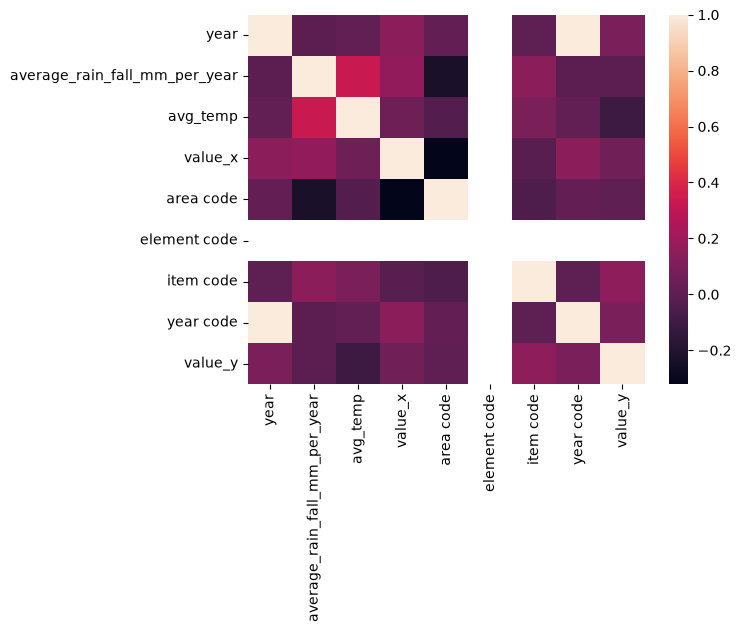

In [81]:
sns.heatmap(corr_matrix)

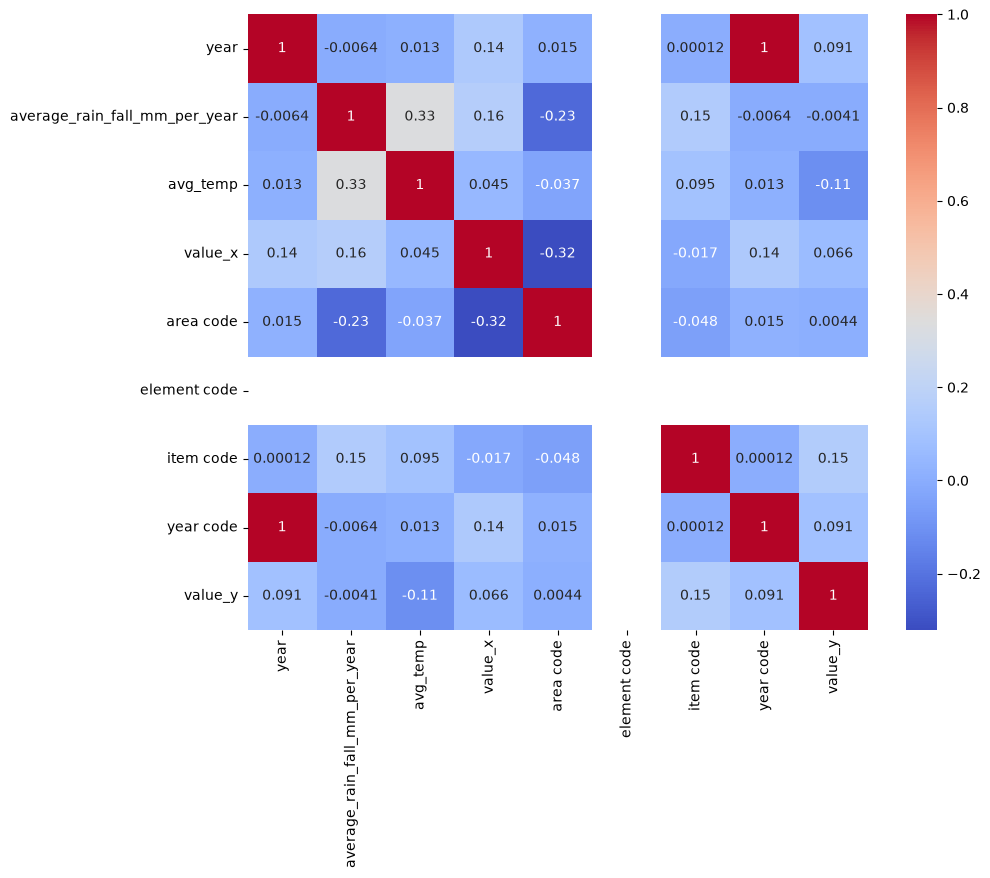

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")
plt.show()

In [83]:
# Supprimons year_code
df = df.drop('year code', axis=1)

In [84]:
df

,area,year,average_rain_fall_mm_per_year,avg_temp,domain_x,element_x,item_x,unit_x,value_x,domain code,domain_y,area code,element code,element_y,item code,item_y,unit_y,value_y
0,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,56,Maize,hg/ha,36613
1,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,116,Potatoes,hg/ha,66667
2,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,27,"Rice, paddy",hg/ha,23333
3,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,83,Sorghum,hg/ha,12500
4,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,236,Soybeans,hg/ha,7000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28243,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,27,"Rice, paddy",hg/ha,22581
28244,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,83,Sorghum,hg/ha,3066
28245,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,236,Soybeans,hg/ha,13142
28246,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,122,Sweet potatoes,hg/ha,22222


In [85]:
yield_df['hg/ha_yield']

0        36613
1        66667
2        23333
3        12500
4         7000
         ...  
28237    22581
28238     3066
28239    13142
28240    22222
28241    22888
Name: hg/ha_yield, Length: 28242, dtype: int64

In [86]:
# Renomons nos colonnes value_x qui represente les pesticides_tonnes et value_y qui répresente la target
df = df.rename(columns={
    "value_x": "pesticides_tonnes",
    "value_y": "hg/ha_yield"
})

In [87]:
df

,area,year,average_rain_fall_mm_per_year,avg_temp,domain_x,element_x,item_x,unit_x,pesticides_tonnes,domain code,domain_y,area code,element code,element_y,item code,item_y,unit_y,hg/ha_yield
0,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,56,Maize,hg/ha,36613
1,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,116,Potatoes,hg/ha,66667
2,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,27,"Rice, paddy",hg/ha,23333
3,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,83,Sorghum,hg/ha,12500
4,Albania,1990,1485.0,16.37,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,121.00,QC,Crops,3,5419,Yield,236,Soybeans,hg/ha,7000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28243,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,27,"Rice, paddy",hg/ha,22581
28244,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,83,Sorghum,hg/ha,3066
28245,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,236,Soybeans,hg/ha,13142
28246,Zimbabwe,2013,657.0,19.76,Pesticides Use,Use,Pesticides (total),tonnes of active ingredients,2550.07,QC,Crops,181,5419,Yield,122,Sweet potatoes,hg/ha,22222


In [88]:
df.columns

Index(['area', 'year', 'average_rain_fall_mm_per_year', 'avg_temp', 'domain_x',
       'element_x', 'item_x', 'unit_x', 'pesticides_tonnes', 'domain code',
       'domain_y', 'area code', 'element code', 'element_y', 'item code',
       'item_y', 'unit_y', 'hg/ha_yield'],
      dtype='object')

In [89]:
df['item_y']

0                 Maize
1              Potatoes
2           Rice, paddy
3               Sorghum
4              Soybeans
              ...      
28243       Rice, paddy
28244           Sorghum
28245          Soybeans
28246    Sweet potatoes
28247             Wheat
Name: item_y, Length: 25938, dtype: object

In [90]:
yield_df.columns

Index(['unnamed: 0', 'area', 'item', 'year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [91]:
df = df.rename(columns={
    'item_y' : 'item'
    })

In [92]:
df.columns

Index(['area', 'year', 'average_rain_fall_mm_per_year', 'avg_temp', 'domain_x',
       'element_x', 'item_x', 'unit_x', 'pesticides_tonnes', 'domain code',
       'domain_y', 'area code', 'element code', 'element_y', 'item code',
       'item', 'unit_y', 'hg/ha_yield'],
      dtype='object')

In [93]:
cols_to_drop = [
    'domain_x',
    'element_x',
    'item_x',
    'unit_x',
    'domain code',
    'domain_y',
    'area code',
    'element code',
    'element_y',
    'item code',
    'unit_y'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [94]:
df.columns

Index(['area', 'year', 'average_rain_fall_mm_per_year', 'avg_temp',
       'pesticides_tonnes', 'item', 'hg/ha_yield'],
      dtype='object')

In [95]:
# Comparons notre jeu de donnée à celui de  yield_df
print(yield_df.shape)
print(df.shape)

(28242, 8)
(25938, 7)


In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df['area'].duplicated().sum()

np.int64(25837)

In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df.duplicated(
    subset=['area', 'year', 'item']
).sum()

np.int64(12802)

In [100]:
df[df.duplicated(
    subset=['area', 'year', 'item'],
    keep=False
)].head(20)

,area,year,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes,item,hg/ha_yield
377,Argentina,1990,591.0,17.46,26156.0,Cassava,100000
378,Argentina,1990,591.0,17.46,26156.0,Maize,34608
379,Argentina,1990,591.0,17.46,26156.0,Potatoes,202747
380,Argentina,1990,591.0,17.46,26156.0,"Rice, paddy",36709
381,Argentina,1990,591.0,17.46,26156.0,Sorghum,28116
382,Argentina,1990,591.0,17.46,26156.0,Soybeans,21566
383,Argentina,1990,591.0,17.46,26156.0,Sweet potatoes,131864
384,Argentina,1990,591.0,17.46,26156.0,Wheat,18947
385,Argentina,1990,591.0,17.67,26156.0,Cassava,100000
386,Argentina,1990,591.0,17.67,26156.0,Maize,34608


In [101]:
temp[
    (temp['area'] == 'Argentina') &
    (temp['year'] == 1990)
]

,year,area,avg_temp
17130,1990,Argentina,17.46
55988,1990,Argentina,17.67


In [102]:
yield_df['area'].duplicated().sum()

np.int64(28141)

In [103]:
yield_df['year'].duplicated().sum()

np.int64(28219)

In [104]:
df["area"].duplicated().sum()

np.int64(25837)

* Conclusion
    * Au début nous avions 5 jeux de données qui sont (rainfall,pesticides,temp,yield,yield_df)
        * Nous avons pris en compte les 4 prémiers et le dernier nous l'avons pris pour une référence parce qu'il contenait déjà les éléments nécessaires de la partie modélisation

        * Alors nous avons fait un pré-traitement des colonnes pour une uniformité après effectué une jointure interne à travers Area et Year qui se répétait dans chaque jeu de donnée
    * Au final nous avions eu un jeu de donnée fusionner composé des 4 et à ce niveau avions aussi effectué une EDA pour avoir un jeu de donnée de léger dans la phase de modélisation

In [105]:
df

,area,year,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes,item,hg/ha_yield
0,Albania,1990,1485.0,16.37,121.00,Maize,36613
1,Albania,1990,1485.0,16.37,121.00,Potatoes,66667
2,Albania,1990,1485.0,16.37,121.00,"Rice, paddy",23333
3,Albania,1990,1485.0,16.37,121.00,Sorghum,12500
4,Albania,1990,1485.0,16.37,121.00,Soybeans,7000
...,...,...,...,...,...,...,...
28243,Zimbabwe,2013,657.0,19.76,2550.07,"Rice, paddy",22581
28244,Zimbabwe,2013,657.0,19.76,2550.07,Sorghum,3066
28245,Zimbabwe,2013,657.0,19.76,2550.07,Soybeans,13142
28246,Zimbabwe,2013,657.0,19.76,2550.07,Sweet potatoes,22222


In [106]:
df.shape

(25938, 7)

### Phase de modélisation 

* Mise en place d'un pipeline

* Pour une prémière modélisation nous allons utiliser logistic regression qui va nous permettre de baseline

In [107]:
data = df.copy()

* Notre target doit être transformé pour avoir une asymétrie équilibré

In [108]:
from scipy.stats import skew

print(skew(data["hg/ha_yield"]))

1.8078924313420612


<Axes: xlabel='hg/ha_yield', ylabel='Count'>

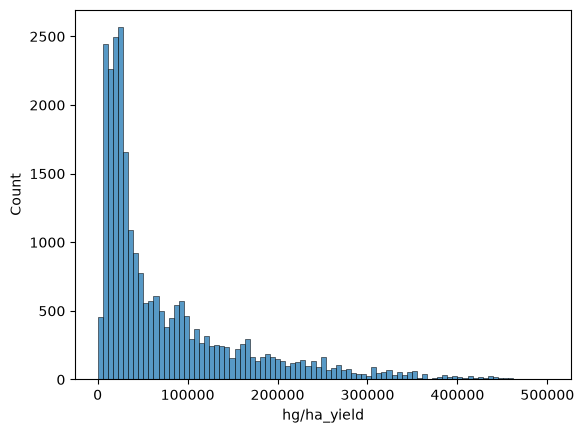

In [109]:
sns.histplot(data['hg/ha_yield'])

In [110]:
import numpy as np
data['hg/ha_yield_log'] = np.log1p(data['hg/ha_yield'])

In [111]:
from scipy.stats import skew

print(skew(data["hg/ha_yield_log"]))

-0.07193648901114422


<Axes: xlabel='hg/ha_yield_log', ylabel='Count'>

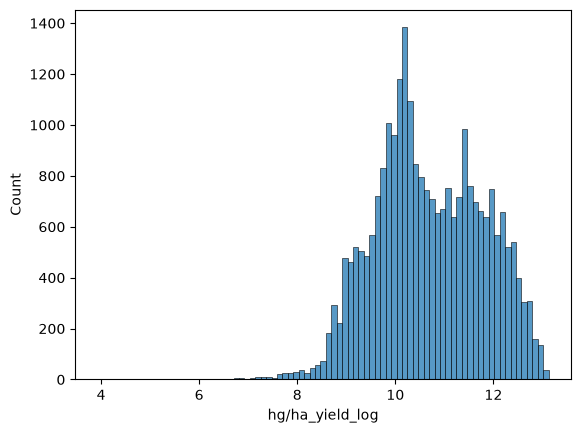

In [112]:
sns.histplot(data['hg/ha_yield_log'])

In [113]:
# Séparation du jeu de données en variables explicatives et variable cible
X = data.drop(columns=['hg/ha_yield','hg/ha_yield_log'], axis=1)
y = data['hg/ha_yield']

In [114]:
X.columns

Index(['area', 'year', 'average_rain_fall_mm_per_year', 'avg_temp',
       'pesticides_tonnes', 'item'],
      dtype='object')

* Pour l'expérimentation de mlflow nous allons créer 2 expériences pour comparer entre la trasnformation logarithmique et celle normale qui apportent les meilleures performances 

In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "area",
    "item"
]

numeric_features = [
    "year",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "pesticides_tonnes"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* Pour le modèle sans transformation

In [211]:
import mlflow
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
mlflow.set_tracking_uri("http://localhost:5000")
with mlflow.start_run(run_name="LinearRegression_Original_Target"):

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = root_mean_squared_error(
        y_test,
        y_pred
    )

    r2 = r2_score(y_test, y_pred)

    mlflow.log_param(
        "target",
        "hg_ha_yield"
    )

    mlflow.log_param(
        "model",
        "LinearRegression"
    )

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    print(mae, rmse, r2)

32939.376486796966 52939.075732394995 0.6284457807212089
🏃 View run LinearRegression_Original_Target at: http://localhost:5000/#/experiments/0/runs/5bdf7e32bd934501bc6f1dcfdd6edb12
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [126]:
X = data.drop(columns=['hg/ha_yield','hg/ha_yield_log'], axis=1)
y = data['hg/ha_yield_log']

In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "area",
    "item"
]

numeric_features = [
    "year",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "pesticides_tonnes"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [216]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [218]:
import mlflow
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
mlflow.set_tracking_uri("http://localhost:5000")
with mlflow.start_run(run_name="LinearRegression_Log_Target"):

    pipeline.fit(X_train, y_train)

    y_pred_log = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred_log)

    y_test_original = np.expm1(y_test)

    mae = mean_absolute_error(
        y_test_original,
        y_pred
    )

    rmse = root_mean_squared_error(
        y_test_original,
        y_pred
    )

    r2 = r2_score(
        y_test_original,
        y_pred
    )

    mlflow.log_param(
        "target",
        "log1p(hg_ha_yield)"
    )

    mlflow.log_param(
        "model",
        "LinearRegression"
    )

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    print(mae, rmse, r2)

29594.65600193288 49991.31054084365 0.6686716999204998
🏃 View run LinearRegression_Log_Target at: http://localhost:5000/#/experiments/0/runs/0313f33e69b14f24a12f9d22cf940378
🧪 View experiment at: http://localhost:5000/#/experiments/0


* Après nous allons utiliser des modèles à base d'arbre comme random forest et xgboost pour comparer avec le modèle de logistic regression

In [116]:
X = data.drop(columns=['hg/ha_yield','hg/ha_yield_log'], axis=1)
y = data['hg/ha_yield_log']

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "area",
    "item"
]

numeric_features = [
    "year",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "pesticides_tonnes"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=1
        )
    )
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area','year','average_rain_fall_mm_per_year','avg_temp', 'pesticides_tonnes','item']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [120]:
import numpy as np

y_pred_log = rf_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [121]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_original,
    y_pred
)

rmse = root_mean_squared_error(
    y_test_original,
    y_pred
)

r2 = r2_score(
    y_test_original,
    y_pred
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 4690.4543554591
RMSE : 10778.51635547285
R2 : 0.9845976333224014


* Enregistrons le mdoèle

In [223]:
import mlflow

with mlflow.start_run(run_name="RandomForest_Log_Target"):

    rf_pipeline.fit(X_train, y_train)

    y_pred_log = rf_pipeline.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)

    mae = mean_absolute_error(
        y_test_original,
        y_pred
    )

    rmse = root_mean_squared_error(
        y_test_original,
        y_pred
    )

    r2 = r2_score(
        y_test_original,
        y_pred
    )

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("target", "yield_log")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 20)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    print(mae, rmse, r2)

4690.454355459097 10778.516355472853 0.9845976333224014
🏃 View run RandomForest_Log_Target at: http://localhost:5000/#/experiments/0/runs/d9104f873e2641f0a5bf91494b87b7dc
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [139]:
X = data.drop(columns=['hg/ha_yield','hg/ha_yield_log'], axis=1)
y = data['hg/ha_yield_log']

In [140]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [141]:
from xgboost import XGBRegressor

In [142]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        )
    )
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area','year','average_rain_fall_mm_per_year','avg_temp', 'pesticides_tonnes','item']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [143]:
y_pred_log = xgb_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [248]:
print("Max y_pred_log :", y_pred_log.max())
print("Min y_pred_log :", y_pred_log.min())
print("Nb valeurs > 20 :", (y_pred_log > 20).sum())  # expm1(20) ≈ 485 millions

Max y_pred_log : 13.048377
Min y_pred_log : 6.039725
Nb valeurs > 20 : 0


In [144]:
from sklearn.metrics import (
    mean_squared_error)

y_pred_log = xgb_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(
    y_test_original,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred
    )
)

r2 = r2_score(
    y_test_original,
    y_pred
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 6924.216953786407
RMSE : 13655.089542709236
R2 : 0.975279423599315


In [250]:
with mlflow.start_run(run_name="XGBoost_Log_Target"):

    xgb_pipeline.fit(X_train, y_train)

    y_pred_log = xgb_pipeline.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)

    mae = mean_absolute_error(
        y_test_original,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_original,
            y_pred
        )
    )

    r2 = r2_score(
        y_test_original,
        y_pred
    )

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("target", "yield_log")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 8)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    print(mae, rmse, r2)

6924.216953786407 13655.089542709236 0.975279423599315
🏃 View run XGBoost_Log_Target at: http://localhost:5000/#/experiments/0/runs/8e94c8869c3a46e299cf59d0414faf61
🧪 View experiment at: http://localhost:5000/#/experiments/0


* Place à la validation croisée pour avoir le modèle le plus performant 

In [122]:
from sklearn.model_selection import GridSearchCV

In [123]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [124]:

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="r2"
)
grid_search.fit(X_train, y_train)
print('Meilleur paramètres :', grid_search.best_params_)
best_rf = grid_search.best_estimator_
print('Meilleur score :', grid_search.best_score_)


Meilleur paramètres : {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleur score : 0.9739957618511065


In [125]:
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area','year','average_rain_fall_mm_per_year','avg_temp', 'pesticides_tonnes','item']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [145]:
param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1]
}

In [146]:
grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_xgb.best_params_)
print("Meilleur R² :", grid_xgb.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs paramètres : {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 400}
Meilleur R² : 0.9677021870092375


In [147]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

In [148]:
grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid_ridge,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_ridge.best_params_)
print("Meilleur R² :", grid_ridge.best_score_)

Meilleurs paramètres : {'model__alpha': 10}
Meilleur R² : 0.04137242085520767


* Pour le choix du modèle nous avons entraîner 3 modèles 
    * Linear Regression qui a servis de baseline
    * Random Forest Regressor
    * Xgboost Regressor
* Concernant le modèle qui a la plus grande performance au niveau de la validation croisée est le random Forest Regressor donc à présent ce modèle sera enregistrer et utiliser pour des opérations ultérieures telles que la mise en place d'une api 

In [127]:
# Enregistrons le modèle
import joblib
joblib.dump(best_rf,'best_random_forest.pkl')

['best_random_forest.pkl']

In [128]:
crops = sorted(data['item'].unique().tolist())

In [129]:
crops

['Cassava',
 'Maize',
 'Plantains and others',
 'Potatoes',
 'Rice, paddy',
 'Sorghum',
 'Soybeans',
 'Sweet potatoes',
 'Wheat',
 'Yams']

In [130]:
## Enregistrons les élements item dans une ligne pour une réutilisation ultérieure
import json

with open('crops.json', 'w') as f:
    json.dump(crops, f)

In [143]:
X['year']

0        1990
1        1990
2        1990
3        1990
4        1990
         ... 
28243    2013
28244    2013
28245    2013
28246    2013
28247    2013
Name: year, Length: 25938, dtype: int64

In [147]:
data.columns

Index(['area', 'year', 'average_rain_fall_mm_per_year', 'avg_temp',
       'pesticides_tonnes', 'item', 'hg/ha_yield', 'hg/ha_yield_log'],
      dtype='object')

In [149]:
# À lancer une fois dans ton notebook ou un script séparé
import pandas as pd

pd.DataFrame(
    ["area", "year", "average_rain_fall_mm_per_year",
     "avg_temp", "pesticides_tonnes", "item"],
    columns=["feature_name"]
).to_csv("../api/models/features.csv", index=False)